In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import cloudpickle as pickle
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    HostmassX1Func,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    SNCoordGivenPhysicalSep,
)
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncomso_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint

from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from lightcurvelynx.validation.lcfit import fit_single_lc

from utils.plotting_utils import convert_flux_to_njy

In [3]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [4]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [5]:
%%time

obs_log = pd.read_parquet('data/ztf_observing_log_combined_w_metadata.parquet')
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"scibckgnd",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=4*6144.* pixel_scale * u.arcsec, 
                                 height=4*6160.* pixel_scale * u.arcsec, angle=0.0 * u.deg)
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap,detector_footprint=ztf_fp)
# ztf_obstable.radius = 3.868

t_min, t_max = ztf_obstable.time_bounds()
print(f"Loaded OpSim with {len(ztf_obstable)} rows and times [{t_min}, {t_max}]")

passband_group = PassbandGroup.from_preset(preset="ZTF", filters=["g", "r", "i"])
print(f"Loaded Passbands: {passband_group}")

Loaded OpSim with 520115 rows and times [58288.171875, 59273.5546875]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i
CPU times: user 497 ms, sys: 84.9 ms, total: 582 ms
Wall time: 527 ms


In [6]:
# randomly pick an SN in the data release to simulate
# ZTF20abegoix - this one looks good for paper
# ZTF19aazlsfj - what happens to this one
# random_sn = data.sample()
random_sn = data.loc[data.ztfname == "ZTF19aazlsfj"]
random_sn

,Unnamed: 0,ztfname,redshift,redshift_err,source,t0,x0,x1,c,t0_err,...,fitquality_flag,iau_name,frac_fitted,ra_host,dec_host,mass,mass_err,restframe_gz,restframe_gz_err,d_dlr
1423,1423,ZTF19aazlsfj,0.071518,0.000028,z_gal,58658.783683,0.000855,-1.047035,-0.105886,0.189968,...,1.0,2019hql,100.0,324.612983,0.553085,10.555,0.105622,1.207697,0.019849,5.526916


<Axes: >

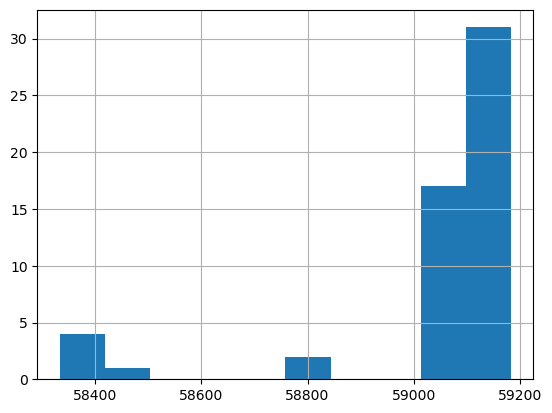

In [7]:
ra = random_sn.ra.values[0]
dec = random_sn.dec.values[0]
idx = ztf_obstable.range_search(ra,dec)
table = ztf_obstable._table.iloc[idx]
table['time'].hist()

In [8]:
H0 = 70.0
Omega_m = 0.3

host = SNIaHost(
    ra = random_sn.ra_host,
    dec = random_sn.dec,
    hostmass= random_sn.mass,
    redshift=random_sn.redshift,
    node_label="host",
)

In [9]:
sncosmo_modelname = "salt3"
source = SncosmoWrapperModel(
    sncosmo_modelname,
    t0=random_sn.t0.values[0],
    x0=random_sn.x0.values[0],
    x1=random_sn.x1.values[0],
    c=random_sn.c.values[0],
    ra=random_sn.ra.values[0],
    dec=random_sn.dec.values[0],
    redshift=random_sn.redshift.values[0],
    node_label="source",
)
    
mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)

# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", frame='observer', ebv=mwextinction, Rv=3.1)
source.add_effect(ext_effect)


In [10]:
nsntotal = 100
lightcurves = simulate_lightcurves(source, int(nsntotal), ztf_obstable, passband_group)
lightcurves

id         ra       dec  nobs            t0         z  \
0    0  324.61651  0.546694    55  58658.783683  0.071518   
1    1  324.61651  0.546694    55  58658.783683  0.071518   
..  ..        ...       ...   ...           ...       ...   
98  98  324.61651  0.546694    55  58658.783683  0.071518   
99  99  324.61651  0.546694    55  58658.783683  0.071518   

                                               params  \
0   {'source.ra': 324.61651, 'source.dec': 0.54669...   
1   {'source.ra': 324.61651, 'source.dec': 0.54669...   
..                                                ...   
98  {'source.ra': 324.61651, 'source.dec': 0.54669...   
99  {'source.ra': 324.61651, 'source.dec': 0.54669...   

                                           lightcurve  
0   [{mjd: 58333.414062, filter: 'g', flux: -1857....  
1   [{mjd: 58333.414062, filter: 'g', flux: -4114....  
..                                                ...  
98  [{mjd: 58333.414062, filter: 'g', flux: 1807.7...  
99  [{mjd: 58333.414062, filter: 'g', flux: -7176....  

[100 rows x 8 columns]

In [11]:
lightcurves = lightcurves.rename(columns={"lightcurve":"lc"})
lightcurves = lightcurves.dropna(subset="lc")

In [12]:
lightcurves['lc.snr'] = lightcurves['lc.flux']/lightcurves['lc.fluxerr']
detection_snr_thres = 5.
lightcurves['lc.detection_flag'] = lightcurves['lc.snr'] > detection_snr_thres
# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lc.is_saturated==False").dropna()
# drop non detection
lightcurves_after_detection = lightcurves_after_drop_sat.query("lc.detection_flag == True").dropna()

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1351: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1351: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


In [13]:
def filter_flags(lc_flag, flags_to_exclude=[], flags_to_include=[]):
    pass_filter = True
    if len(flags_to_include)>0:
        pass_filter &= np.all([lc_flag & flag != 0 for flag in flags_to_include])
    if len(flags_to_exclude)>0:
        pass_filter &= np.all([lc_flag & flag == 0 for flag in flags_to_exclude])
    return pass_filter

[20]
x0 0.0008554930030518
x1 -1.0470346880713302
c -0.1058857596646517
z 0.07151812
mwebv 0.05514343190117112


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:326: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1351: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/utils/plotting.py:112: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.

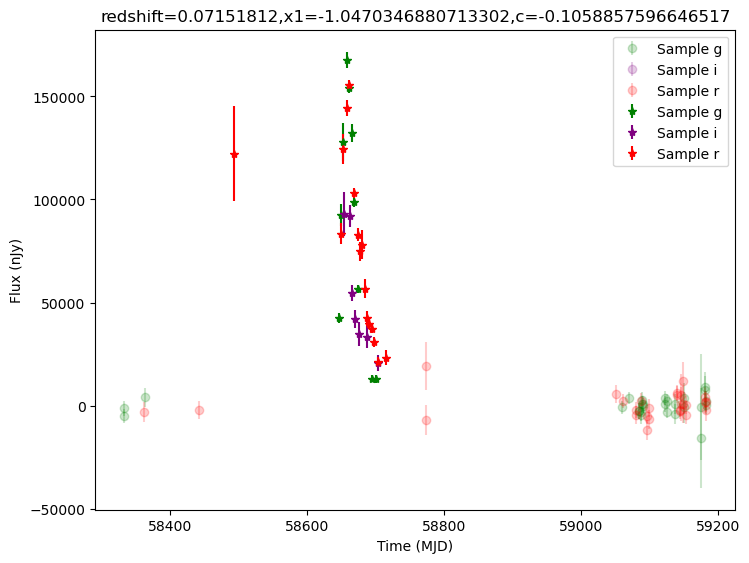

In [19]:
sncosmo_modelname = "salt3"
random_ids = lightcurves.id.sample(1).values
colormap = {'g':'g',
            'r':'r',
            'i':'purple',}
print(random_ids)

for random_id in random_ids:
    # Extract the row for this object.
    lc = lightcurves.loc[lightcurves.id==random_id]
    # lc = lc.query("lc.detection_flag==True")
    
    state = GraphState.from_dict(lc.iloc[0]["params"])
    noise_free_lcs = compute_single_noise_free_lightcurve(
        source,
        state,
        passband_group,
        rest_frame_phase_min=-20.0, 
        rest_frame_phase_max=50.0, 
        rest_frame_phase_step=0.5, 
    )
    
    if lc["nobs"].values[0] > 0:
        # Unpack the nested columns (filters, mjd, flux, and flux error).
        lc_filters = np.asarray(lc["lc.filter"], dtype=str)
        lc_mjd = np.asarray(lc["lc.mjd"], dtype=float)
        lc_flux = np.asarray(lc["lc.flux"], dtype=float)
        lc_fluxerr = np.asarray(lc["lc.fluxerr"], dtype=float)
        
        ax = plot_lightcurves(
            fluxes=lc_flux,
            times=lc_mjd,
            fluxerrs=lc_fluxerr,
            filters=lc_filters,
            colormap=colormap,
            underlying_model=None,#noise_free_lcs,
            alpha = 0.2,
        )
        plt.ylabel('Flux (nJy)')
        # plt.title(f"redshift={lc['z']},mwebv={lc['params'].values[0]['mwext.ebv']}")
        plt.title(f"redshift={lc['z'].values[0]},x1={lc['params'].values[0]['source.x1']},c={lc['params'].values[0]['source.c']}")
        for par in ['x0','x1','c']:
            print(par,lc['params'].values[0][f'source.{par}'])
        print('z',lc['z'].values[0])
        print('mwebv',lc['params'].values[0]['mwext.ebv'])
             
        # plt.legend()
        # plt.show()

    random_lc = lcdata.loc[lcdata["ztfname"] == random_sn.ztfname.values[0]]

    random_lc["lc.pass_flag_filter"] = random_lc["lc.flag"].apply(filter_flags,flags_to_exclude=[],flags_to_include=[1024])
    lc_plot = random_lc.query("lc.pass_flag_filter == True").dropna(subset="lc")
    # lc_plot = random_lc
    
    #plot the data
    lc_plot["lc.flux"], lc_plot["lc.flux_err"] = convert_flux_to_njy(lc_plot["lc.flux"],lc_plot["lc.flux_err"],zp=30.)
    
    plot_lightcurves(
        fluxes=lc_plot["lc.flux"],
        times=lc_plot["lc.mjd"],
        fluxerrs=lc_plot["lc.flux_err"],
        filters=[x[-1] for x in lc_plot["lc.filter"]],
        colormap=colormap,
        ax = ax,
        marker = "*",
    )

    # t_min, t_max = random_sn.t0.values[0] - 20*(1+lc['z'].values[0]), random_sn.t0.values[0] + 50*(1+lc['z'].values[0])
    # plt.xlim((t_min,t_max))
    # plt.ylim((-1e5,mag2flux(18.)))

In [20]:
lynx_lc = lc.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1351: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1351: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


In [21]:
lynx_lc

,mjd,filter,flux,fluxerr,flux_perfect,survey_idx,is_saturated,snr,detection_flag
0,58333.414062,g,-5168.768517,3446.090394,0.0,0,False,-1.499893,False
1,58333.414062,g,-1348.241712,3633.308887,0.0,0,False,-0.371078,False
...,...,...,...,...,...,...,...,...,...
53,59183.164062,g,495.179532,4647.788186,0.0,0,False,0.106541,False
54,59183.164062,g,2244.778392,4847.323673,0.0,0,False,0.463096,False


In [22]:
ztf_lc

,mjd,filter,flux,flux_err,ZP,flag,mag,mag_err,field_id,rcid,flux_offset,offset_unc,err_scale,in_baseline,pass_flag_filter
0,58493.08674,ztfr,122293.633238,23262.320272,30.0,1224,18.68149,0.20653,442,60.0,-283.88219,94.87496,1.0,0,True
1,58647.46514,ztfg,42596.464214,2493.772682,30.0,1280,19.82657,0.06356,442,60.0,-270.43297,85.33833,1.0,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,58703.40056,ztfr,21077.719592,2349.238715,30.0,1280,20.59044,0.12101,442,60.0,-283.88219,94.87496,1.0,0,True
32,58715.36574,ztfr,23183.338124,3575.989237,30.0,1024,20.48706,0.16747,442,60.0,-283.88219,94.87496,1.0,0,True


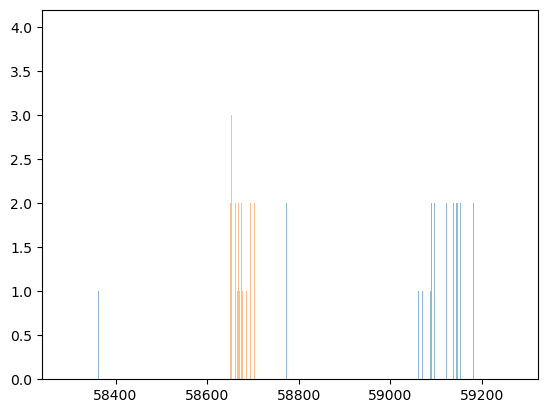

In [23]:
bins = np.arange(t_min,t_max,1)
plt.hist(lynx_lc.mjd,bins=bins,alpha=0.5)
plt.hist(ztf_lc.mjd,bins=bins,alpha=0.5)
plt.show()